<a href="https://colab.research.google.com/github/JannatLima/earthquake-blast-classification-ml/blob/main/earthquake_blast_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
#-------Cell 1---------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [27]:
#-------Cell 2---------#
qb_url = ("https://earthquake.usgs.gov/fdsnws/event/1/query?"
          "format=csv&starttime=2000-01-01&endtime=2024-12-31"
          "&minmagnitude=1.0&maxmagnitude=4.5"
          "&eventtype=quarry%20blast&limit=20000&orderby=time")

quarry_df = pd.read_csv(qb_url)
quarry_df['Type'] = 'Quarry Blast'
print("Quarry blast events found:", len(quarry_df))
print(quarry_df.columns.tolist())

Quarry blast events found: 20000
['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource', 'Type']


In [28]:
#-------Cell 3---------#
import time

eq_limit_total = int(min(len(quarry_df) * 4, 20000))

# Split 2000-2024 into yearly chunks, pull a slice from each year,
# so earthquakes span the same period as the quarry blasts
years = list(range(2000, 2025))
per_year_limit = int(np.ceil(eq_limit_total / len(years)))

eq_frames = []
for year in years:
    url = (f"https://earthquake.usgs.gov/fdsnws/event/1/query?"
           f"format=csv&starttime={year}-01-01&endtime={year}-12-31"
           f"&minmagnitude=1.0&maxmagnitude=4.5"
           f"&eventtype=earthquake&limit={per_year_limit}&orderby=time")
    try:
        chunk = pd.read_csv(url)
        eq_frames.append(chunk)
        print(f"{year}: {len(chunk)} events")
    except Exception as e:
        print(f"{year}: failed ({e})")
    time.sleep(1)  # be polite to the USGS server between requests

earthquake_df = pd.concat(eq_frames, ignore_index=True)
earthquake_df['Type'] = 'Earthquake'
print("\nTotal earthquake events found:", len(earthquake_df))

2000: 800 events
2001: 800 events
2002: 800 events
2003: 800 events
2004: 800 events
2005: 800 events
2006: 800 events
2007: 800 events
2008: 800 events
2009: 800 events
2010: 800 events
2011: 800 events
2012: 800 events
2013: 800 events
2014: 800 events
2015: 800 events
2016: 800 events
2017: 800 events
2018: 800 events
2019: 800 events
2020: 800 events
2021: 800 events
2022: 800 events
2023: 800 events
2024: 800 events

Total earthquake events found: 20000


In [29]:
#-------Cell 4---------#
df = pd.concat([quarry_df, earthquake_df], ignore_index=True)
print("Final class balance:")
print(df['Type'].value_counts())
df.head()

Final class balance:
Type
Quarry Blast    20000
Earthquake      20000
Name: count, dtype: int64


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,Type
0,2024-12-30T21:59:10.160Z,45.081833,-111.730333,-2.00,1.00,ml,8.0,141.0,0.112600,0.08,...,"29 km SE of Virginia City, Montana",quarry blast,0.55,31.61,0.231783,11.0,reviewed,mb,mb,Quarry Blast
1,2024-12-30T00:23:34.200Z,35.041667,-117.665000,-0.79,1.78,ml,36.0,75.0,0.110100,0.14,...,"5 km NNW of Boron, CA",quarry blast,0.28,31.61,0.149000,45.0,reviewed,ci,ci,Quarry Blast
2,2024-12-27T22:59:06.000Z,34.268000,-96.369500,0.00,1.09,ml,33.0,133.0,0.224056,0.46,...,"12 km SSE of Wapanucka, Oklahoma",quarry blast,NaN,0.70,0.120000,15.0,reviewed,ok,ok,Quarry Blast
3,2024-12-27T20:01:49.790Z,46.006667,-112.465667,-2.00,1.48,ml,9.0,84.0,0.063560,0.09,...,"5 km E of Butte, Montana",quarry blast,0.39,31.61,0.277503,16.0,reviewed,mb,mb,Quarry Blast
4,2024-12-26T20:45:13.150Z,35.046000,-118.323333,-0.93,1.45,ml,29.0,40.0,0.057260,0.15,...,"14 km W of Mojave, CA",quarry blast,0.25,31.61,0.139000,22.0,reviewed,ci,ci,Quarry Blast


In [30]:
#-------Cell 5---------#
physical_cols = [
    'latitude',
    'longitude',
    'depth',
    'mag',
    'nst',
    'gap',
    'dmin',
    'rms',
    'horizontalError',
    'depthError',
    'magError',
    'magNst'
]

df_physical = df[[c for c in physical_cols + ['Type'] if c in df.columns]].copy()

print("Dataset shape:", df_physical.shape)
print("\nClass distribution:")
print(df_physical['Type'].value_counts())

print("\nMissing values:")
print(df_physical.isnull().sum())

Dataset shape: (40000, 13)

Class distribution:
Type
Quarry Blast    20000
Earthquake      20000
Name: count, dtype: int64

Missing values:
latitude               0
longitude              0
depth                  0
mag                    0
nst                 7326
gap                 6877
dmin                9947
rms                 1391
horizontalError    11945
depthError          2217
magError           10652
magNst              8283
Type                   0
dtype: int64


In [31]:
#-------Cell 6---------#
X_raw = df_physical.drop('Type', axis=1)
y_raw = df_physical['Type']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Classes:", label_encoder.classes_)
print("Encoded classes:", np.unique(y))

Classes: ['Earthquake' 'Quarry Blast']
Encoded classes: [0 1]


In [32]:
#-------Cell 7---------#
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_raw))
print("Testing samples :", len(X_test_raw))

Training samples: 32000
Testing samples : 8000


In [33]:
#-------Cell 8---------#
train_medians = X_train_raw.median(numeric_only=True)

X_train_imputed = X_train_raw.fillna(train_medians)
X_test_imputed = X_test_raw.fillna(train_medians)  # same values from train, never test

print("Remaining missing values in train:", X_train_imputed.isnull().sum().sum())
print("Remaining missing values in test:", X_test_imputed.isnull().sum().sum())

Remaining missing values in train: 0
Remaining missing values in test: 0


In [34]:
#-------Cell 9---------#
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_imputed)
X_test = scaler.transform(X_test_imputed)

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (32000, 12)
X_test shape : (8000, 12)


In [35]:
#-------Cell 10---------#
rf_physical = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_physical.fit(X_train, y_train)

rf_pred = rf_physical.predict(X_test)
rf_prob = rf_physical.predict_proba(X_test)[:, 1]

print("=" * 60)
print("RANDOM FOREST — PHYSICAL FEATURES ONLY (leakage-safe)")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall   : {recall_score(y_test, rf_pred):.4f}")
print(f"F1-score : {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

RANDOM FOREST — PHYSICAL FEATURES ONLY (leakage-safe)
Accuracy : 0.9939
Precision: 0.9952
Recall   : 0.9925
F1-score : 0.9939
ROC-AUC  : 0.9998

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99      1.00      0.99      4000
Quarry Blast       1.00      0.99      0.99      4000

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000


Confusion Matrix:
[[3981   19]
 [  30 3970]]


In [36]:
#-------Cell 11---------#
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,658 (10.38 KB)

 Trainable params: 2,658 (10.38 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
#-------Cell 12---------#
monitor = EarlyStopping(monitor='val_loss', patience=5, verbose=1,
                         mode='min', restore_best_weights=True)

checkpoint = ModelCheckpoint('./best_weights_physical.keras', monitor='val_loss',
                              mode='min', save_best_only=True, verbose=1)

reduceLR = ReduceLROnPlateau()
callback_list = [monitor, checkpoint, reduceLR]

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
#-------Cell 13---------#
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights:", class_weight_dict)

history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    batch_size=32,
    epochs=50,
    callbacks=callback_list,
    class_weight=class_weight_dict,
    verbose=1
)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Epoch 1/50
789/800 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8794 - loss: 0.3079
Epoch 1: val_loss improved from None to 0.11434, saving model to ./best_weights_physical.keras

Epoch 1: finished saving model to ./best_weights_physical.keras
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9267 - loss: 0.2058 - val_accuracy: 0.9503 - val_loss: 0.1143 - learning_rate: 0.0010
Epoch 2/50
794/800 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9591 - loss: 0.1057
Epoch 2: val_loss improved from 0.11434 to 0.09307, saving model to ./best_weights_physical.keras

Epoch 2: finished saving model to ./best_weights_physical.keras
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9612 - loss: 0.1022 - val_accuracy: 0.9614 - val_loss: 0.0931 - learning_rate: 0.0010
Epoch 3/50
797/800 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9656 - loss: 0.0850
Epoch 3: val_loss improved from 0.09307 to 0.08181, saving model to ./best_weigh

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9831 - loss: 0.0472
Neural Network Test Accuracy: 0.9831
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report (Neural Network, physical features only):
              precision    recall  f1-score   support

  Earthquake       0.98      0.99      0.98      4000
Quarry Blast       0.99      0.98      0.98      4000

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000



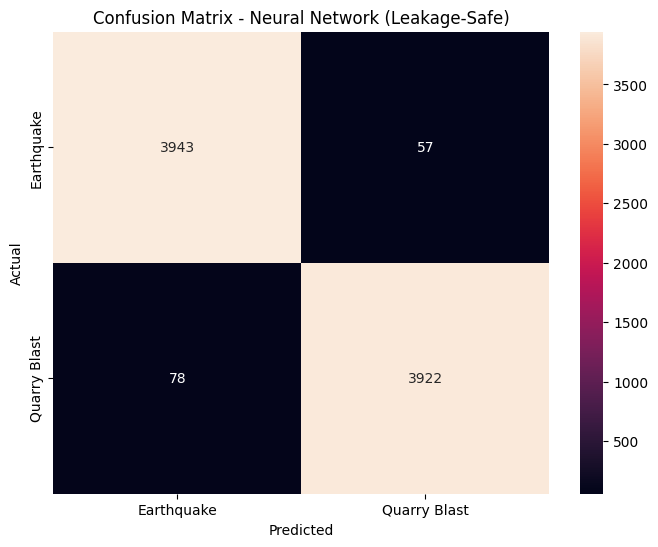

In [39]:
#-------Cell 14---------#
test_loss, test_acc_nn = model.evaluate(X_test, y_test_cat)
print(f"Neural Network Test Accuracy: {test_acc_nn:.4f}")

y_pred_probs = model.predict(X_test)
y_pred_nn = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report (Neural Network, physical features only):")
print(classification_report(y_test, y_pred_nn, target_names=label_encoder.classes_))

cf_matrix = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(cf_matrix, annot=True, fmt="d",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Neural Network (Leakage-Safe)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

            Feature  Importance
2             depth    0.485573
9        depthError    0.220161
1         longitude    0.103560
0          latitude    0.076089
3               mag    0.039593
7               rms    0.019606
6              dmin    0.018210
8   horizontalError    0.009379
11           magNst    0.009164
10         magError    0.006691
4               nst    0.006203
5               gap    0.005772


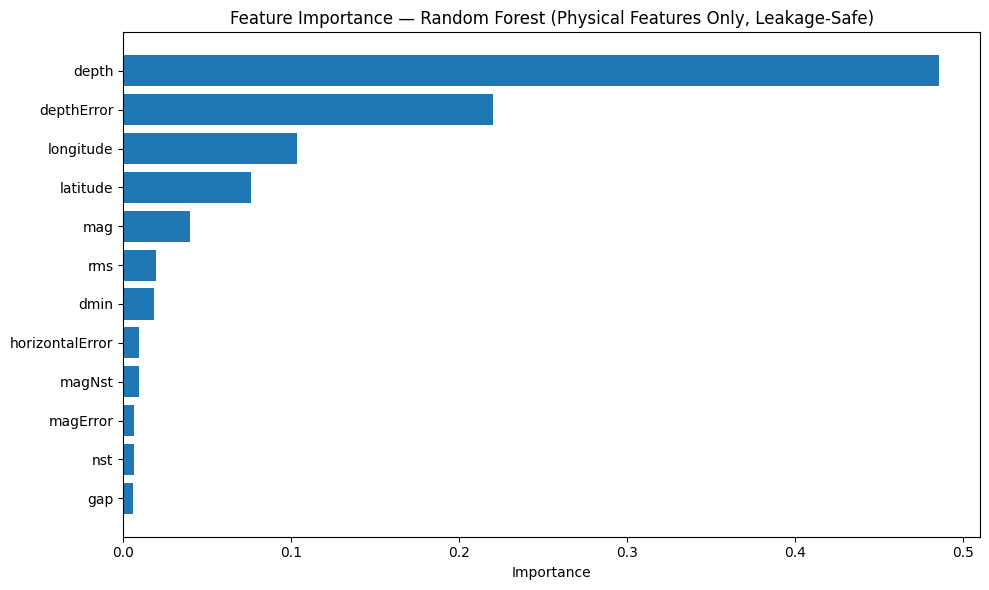

In [40]:
#-------Cell 15---------#
feature_names = X_raw.columns.tolist()
importances = rf_physical.feature_importances_

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feat_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance_df['Feature'], feat_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance — Random Forest (Physical Features Only, Leakage-Safe)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [41]:
#-------Cell 16---------#
print("depthError statistics by event type:\n")
print(df_physical.groupby('Type')['depthError'].describe())

print("\nMost common depthError values per type:")
print("\nQuarry Blast top values:")
print(df_physical[df_physical['Type'] == 'Quarry Blast']['depthError'].value_counts().head(10))
print("\nEarthquake top values:")
print(df_physical[df_physical['Type'] == 'Earthquake']['depthError'].value_counts().head(10))

depthError statistics by event type:

                count       mean        std   min    25%    50%    75%     max
Type                                                                          
Earthquake    17783.0   3.536763  54.184532  0.00   0.40   0.73   2.00  6877.4
Quarry Blast  20000.0  25.754557  11.979645  0.12  31.61  31.61  31.61   236.1

Most common depthError values per type:

Quarry Blast top values:
depthError
31.61    15984
0.60       319
0.50       315
0.70       220
0.40       216
0.80       170
0.90       105
0.30        81
1.00        78
1.10        40
Name: count, dtype: int64

Earthquake top values:
depthError
0.3    944
0.2    895
0.4    781
0.1    614
0.5    595
0.6    504
0.0    417
0.7    377
0.8    280
0.9    235
Name: count, dtype: int64


In [42]:
#-------Cell 17---------#
physical_cols_clean = [c for c in physical_cols if c != 'depthError']

X_raw_clean = df_physical[physical_cols_clean]

X_train_raw_clean, X_test_raw_clean, y_train_c, y_test_c = train_test_split(
    X_raw_clean, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

train_medians_clean = X_train_raw_clean.median(numeric_only=True)
X_train_imp_clean = X_train_raw_clean.fillna(train_medians_clean)
X_test_imp_clean = X_test_raw_clean.fillna(train_medians_clean)

scaler_clean = StandardScaler()
X_train_clean = scaler_clean.fit_transform(X_train_imp_clean).astype(np.float32)
X_test_clean = scaler_clean.transform(X_test_imp_clean).astype(np.float32)

rf_clean = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_clean.fit(X_train_clean, y_train_c)
rf_pred_clean = rf_clean.predict(X_test_clean)

print(f"Accuracy without depthError: {accuracy_score(y_test_c, rf_pred_clean):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, rf_pred_clean, target_names=label_encoder.classes_))

Accuracy without depthError: 0.9929

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99      0.99      0.99      4000
Quarry Blast       0.99      0.99      0.99      4000

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000



            Feature  Importance
2             depth    0.620438
1         longitude    0.120832
0          latitude    0.091832
3               mag    0.058898
7               rms    0.026565
6              dmin    0.020914
8   horizontalError    0.016870
10           magNst    0.014388
9          magError    0.013902
5               gap    0.007740
4               nst    0.007620


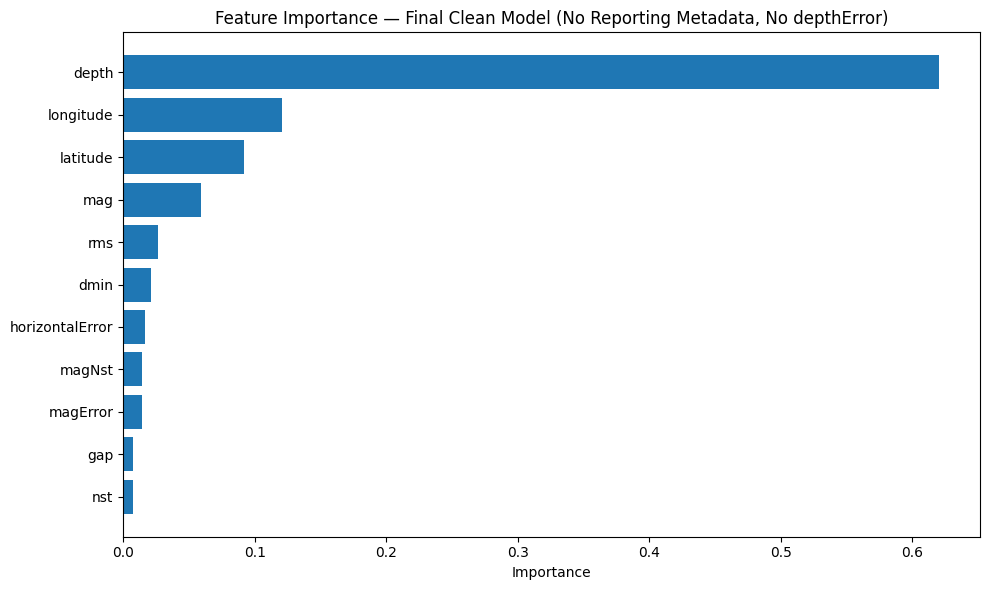

In [43]:
#-------Cell 18---------#
feat_importance_clean = pd.DataFrame({
    'Feature': physical_cols_clean,
    'Importance': rf_clean.feature_importances_
}).sort_values('Importance', ascending=False)

print(feat_importance_clean)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance_clean['Feature'], feat_importance_clean['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance — Final Clean Model (No Reporting Metadata, No depthError)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [44]:
#-------Cell 19---------#
y_train_cat_clean = to_categorical(y_train_c, num_classes=2)
y_test_cat_clean = to_categorical(y_test_c, num_classes=2)

model_clean = Sequential()
model_clean.add(Input(shape=(X_train_clean.shape[1],)))
model_clean.add(Dense(32, activation='relu'))
model_clean.add(Dense(64, activation='relu'))
model_clean.add(Dense(2, activation='softmax'))

model_clean.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

monitor_clean = EarlyStopping(monitor='val_loss', patience=5, verbose=1,
                               mode='min', restore_best_weights=True)
reduceLR_clean = ReduceLROnPlateau()

class_weights_clean = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train_c), y=y_train_c
)
class_weight_dict_clean = dict(enumerate(class_weights_clean))

history_clean = model_clean.fit(
    X_train_clean, y_train_cat_clean,
    validation_split=0.2,
    batch_size=32,
    epochs=50,
    callbacks=[monitor_clean, reduceLR_clean],
    class_weight=class_weight_dict_clean,
    verbose=1
)

Epoch 1/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8932 - loss: 0.2643 - val_accuracy: 0.9584 - val_loss: 0.1322 - learning_rate: 0.0010
Epoch 2/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9563 - loss: 0.1261 - val_accuracy: 0.9606 - val_loss: 0.1130 - learning_rate: 0.0010
Epoch 3/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9595 - loss: 0.1144 - val_accuracy: 0.9658 - val_loss: 0.1035 - learning_rate: 0.0010
Epoch 4/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9630 - loss: 0.1078 - val_accuracy: 0.9655 - val_loss: 0.1007 - learning_rate: 0.0010
Epoch 5/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9638 - loss: 0.1044 - val_accuracy: 0.9667 - val_loss: 0.0960 - learning_rate: 0.0010
Epoch 6/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9649 - loss: 0.0991 - val_accuracy: 0.9697 - val_loss: 0.0981 - learning_rate: 0.0010
Epoch 7/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9661 - loss: 0.0952 - 

In [45]:
#-------Cell 20---------#
test_loss_c, test_acc_nn_clean = model_clean.evaluate(X_test_clean, y_test_cat_clean)
print(f"Neural Network Test Accuracy (final clean): {test_acc_nn_clean:.4f}")

y_pred_probs_clean = model_clean.predict(X_test_clean)
y_pred_nn_clean = np.argmax(y_pred_probs_clean, axis=1)

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_nn_clean, target_names=label_encoder.classes_))

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9806 - loss: 0.0628
Neural Network Test Accuracy (final clean): 0.9806
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.98      0.98      0.98      4000
Quarry Blast       0.98      0.98      0.98      4000

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000



In [46]:
#-------Cell 21---------#
!pip install shap --quiet

import shap

explainer = shap.TreeExplainer(rf_clean)

# SHAP on a sample of the test set (faster than the full 8000 rows)
sample_idx = np.random.choice(X_test_clean.shape[0], 500, replace=False)
X_sample = X_test_clean[sample_idx]

shap_values = explainer.shap_values(X_sample)

print("SHAP values computed. Shape:", np.array(shap_values).shape)

SHAP values computed. Shape: (500, 11, 2)


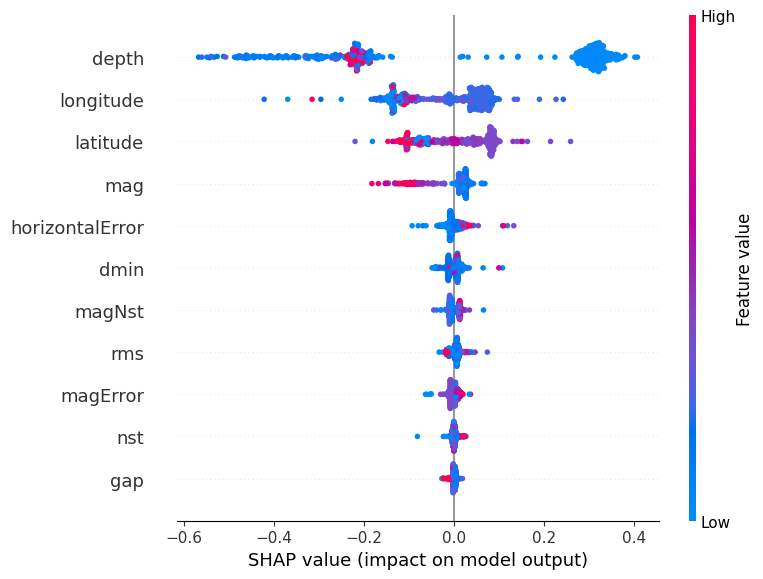

In [47]:
#-------Cell 22---------#
shap.summary_plot(
    shap_values[:, :, 1],  # SHAP values for class 1 (Quarry Blast)
    X_sample,
    feature_names=physical_cols_clean,
    show=True
)